**1. Import Library**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

**2. Load Dataset**

In [2]:
try:
  df = pd.read_csv("../data/raw/video_game_sales.csv")
  print("Dataset loaded successfully.")
except FileNotFoundError:
  print("File not found. Please check the file path.")

Dataset loaded successfully.


**3. Jumlah Baris dan Kolom Dataset**

In [3]:
jumlah_baris = df.shape[0]
jumlah_kolom = df.shape[1]
nama_kolom = [col for col in df.columns]
print(f"Jumlah baris: {jumlah_baris}")
print(f"Jumlah kolom: {jumlah_kolom}")
print(f"Nama kolom: {nama_kolom}")

Jumlah baris: 16598
Jumlah kolom: 11
Nama kolom: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


**4. Lima Baris Data Teratas**

In [4]:
print(df.head())

   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  


**5. Ringkasan Dataset**

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 2.1 MB


**6. Ringkasan Statistik Data Numerik**

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rank,16598.0,8300.605254,4791.853933,1.00,4151.25,8300.50,12449.75,16600.00
Year,16327.0,2006.406443,5.828981,1980.00,2003.00,2007.00,2010.00,2020.00
NA_Sales,16598.0,0.264667,0.816683,0.00,0.00,0.08,0.24,41.49
EU_Sales,16598.0,0.146652,0.505351,0.00,0.00,0.02,0.11,29.02
JP_Sales,16598.0,0.077782,0.309291,0.00,0.00,0.00,0.04,10.22
Other_Sales,16598.0,0.048063,0.188588,0.00,0.00,0.01,0.04,10.57
Global_Sales,16598.0,0.537441,1.555028,0.01,0.06,0.17,0.47,82.74


**7. Cek Apakah Ada Missing Value**

In [7]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

**8. Visualisasi Missing Value**

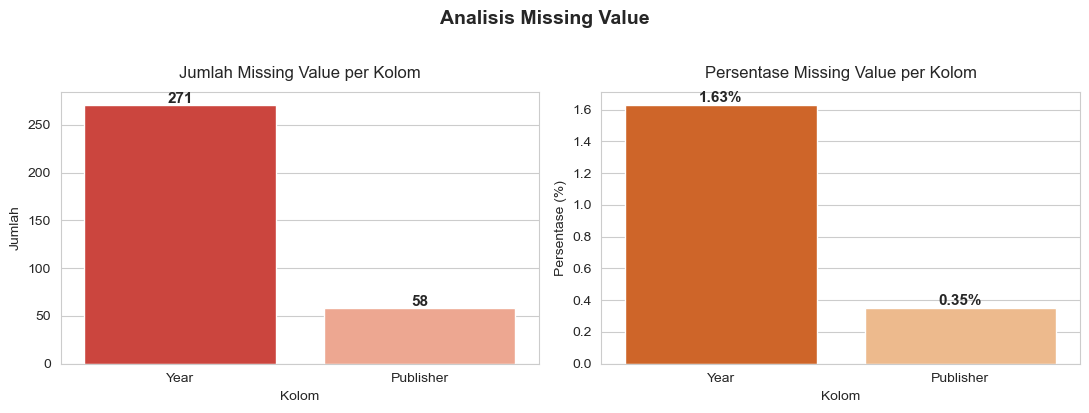

    Kolom  Jumlah Missing  Persentase (%)
     Year             271            1.63
Publisher              58            0.35


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].reset_index()
missing.columns = ['Kolom', 'Jumlah Missing']
missing['Persentase (%)'] = (missing['Jumlah Missing'] / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.set_style('whitegrid')

# Panel kiri: jumlah
bars1 = sns.barplot(data=missing, x='Kolom', y='Jumlah Missing',
                    palette='Reds_r', ax=axes[0])
for bar, val in zip(bars1.patches, missing['Jumlah Missing']):
    bars1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
               str(val), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Jumlah Missing Value per Kolom', fontsize=12, pad=10)
axes[0].set_xlabel('Kolom')
axes[0].set_ylabel('Jumlah')

# Panel kanan: persentase
bars2 = sns.barplot(data=missing, x='Kolom', y='Persentase (%)',
                    palette='Oranges_r', ax=axes[1])
for bar, val in zip(bars2.patches, missing['Persentase (%)']):
    bars2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
               f'{val}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Persentase Missing Value per Kolom', fontsize=12, pad=10)
axes[1].set_xlabel('Kolom')
axes[1].set_ylabel('Persentase (%)')

plt.suptitle('Analisis Missing Value', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(missing.to_string(index=False))

**Insight:** Kolom `Year` memiliki **271 missing value (1.63%)** dan `Publisher` memiliki **58 missing value (0.35%)**. Jumlahnya kecil dibanding total 16.598 baris, sehingga aman dihapus saat preprocessing.

**9. Cek Apakah Ada Duplicate Value**

In [8]:
df.duplicated().sum()

np.int64(0)

**10. Visualisasi Duplicate Value**

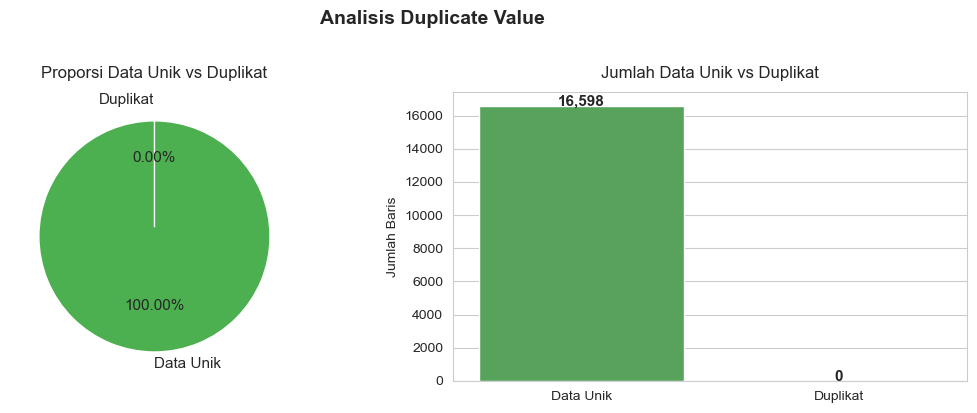

Total baris  : 16,598
Data unik    : 16,598
Duplikat     : 0


In [ ]:
n_duplikat = df.duplicated().sum()
n_unik     = len(df) - n_duplikat

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel kiri: pie chart proporsi
labels  = ['Data Unik', 'Duplikat']
sizes   = [n_unik, n_duplikat]
colors  = ['#4CAF50', '#F44336']
explode = [0, 0.08]
axes[0].pie(sizes, labels=labels, autopct='%1.2f%%', colors=colors,
            explode=explode, startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title('Proporsi Data Unik vs Duplikat', fontsize=12, pad=10)

# Panel kanan: bar chart perbandingan
bar_data = {'Kategori': ['Data Unik', 'Duplikat'], 'Jumlah': [n_unik, n_duplikat]}
import pandas as pd
bar_df = pd.DataFrame(bar_data)
bars = sns.barplot(data=bar_df, x='Kategori', y='Jumlah',
                   palette=['#4CAF50', '#F44336'], ax=axes[1])
for bar, val in zip(bars.patches, bar_df['Jumlah']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
              f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Jumlah Data Unik vs Duplikat', fontsize=12, pad=10)
axes[1].set_xlabel('')
axes[1].set_ylabel('Jumlah Baris')

plt.suptitle('Analisis Duplicate Value', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Total baris  : {len(df):,}")
print(f"Data unik    : {n_unik:,}")
print(f"Duplikat     : {n_duplikat}")

**Insight:** Dataset tidak memiliki baris duplikat, sehingga tidak diperlukan penghapusan pada tahap preprocessing.

**11. Cek Apakah Ada Inconsistent Value**

In [9]:
# Cek unique value genre
print(df['Genre'].unique())

# Hitung jumlah unique genre
print(df['Genre'].nunique())

# Cek unique value platform
print(df['Platform'].unique())

# Hitung jumlah unique platform
print(df['Platform'].nunique())


<ArrowStringArray>
[      'Sports',     'Platform',       'Racing', 'Role-Playing',
       'Puzzle',         'Misc',      'Shooter',   'Simulation',
       'Action',     'Fighting',    'Adventure',     'Strategy']
Length: 12, dtype: str
12
<ArrowStringArray>
[ 'Wii',  'NES',   'GB',   'DS', 'X360',  'PS3',  'PS2', 'SNES',  'GBA',
  '3DS',  'PS4',  'N64',   'PS',   'XB',   'PC', '2600',  'PSP', 'XOne',
   'GC', 'WiiU',  'GEN',   'DC',  'PSV',  'SAT',  'SCD',   'WS',   'NG',
 'TG16',  '3DO',   'GG', 'PCFX']
Length: 31, dtype: str
31


**12. Grafik Top 10 Penjualan Global Genre Game**

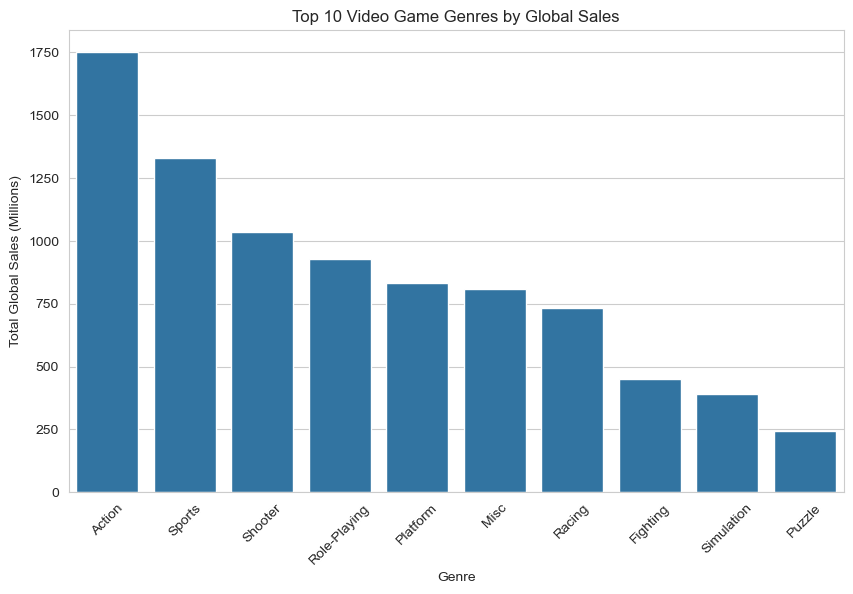

In [11]:
sns.set_style("whitegrid")
genre_sales = (
    df.groupby('Genre')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
plt.figure(figsize=(10,6))

sns.barplot(
    data=genre_sales,
    x='Genre',
    y='Global_Sales'
)

plt.title("Top 10 Video Game Genres by Global Sales")
plt.xlabel("Genre")
plt.ylabel("Total Global Sales (Millions)")

plt.xticks(rotation=45)

plt.show()

**13. Grafik Tren Penjualan Video Game Berdasarkan Tahun Rilis**

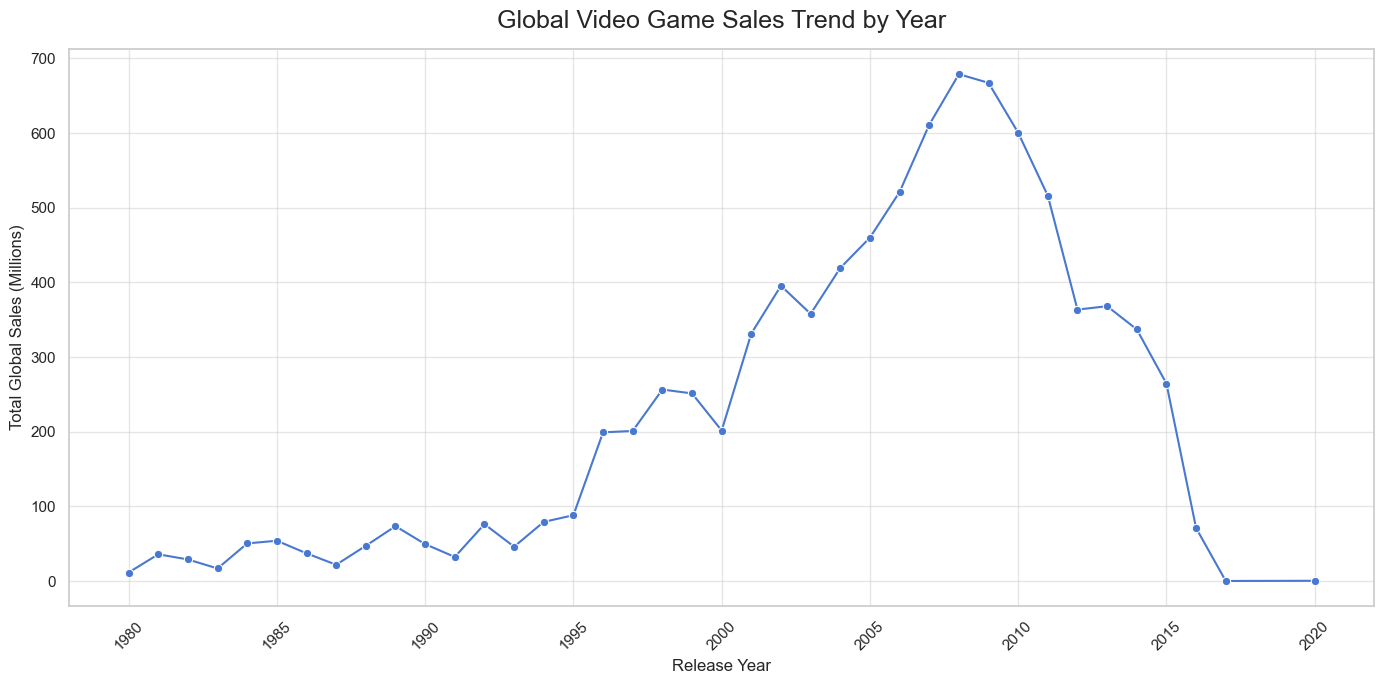

In [19]:
sns.set_style("whitegrid")

df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)

yearly_sales = (
    df.groupby('Year')['Global_Sales']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,7))

sns.lineplot(
    data=yearly_sales,
    x='Year',
    y='Global_Sales',
    marker='o'
)

plt.title(
    "Global Video Game Sales Trend by Year",
    fontsize=18,
    pad=15
)

plt.xlabel(
    "Release Year",
    fontsize=12
)

plt.ylabel(
    "Total Global Sales (Millions)",
    fontsize=12
)

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**14. Grafik Genre Favorit per Region**

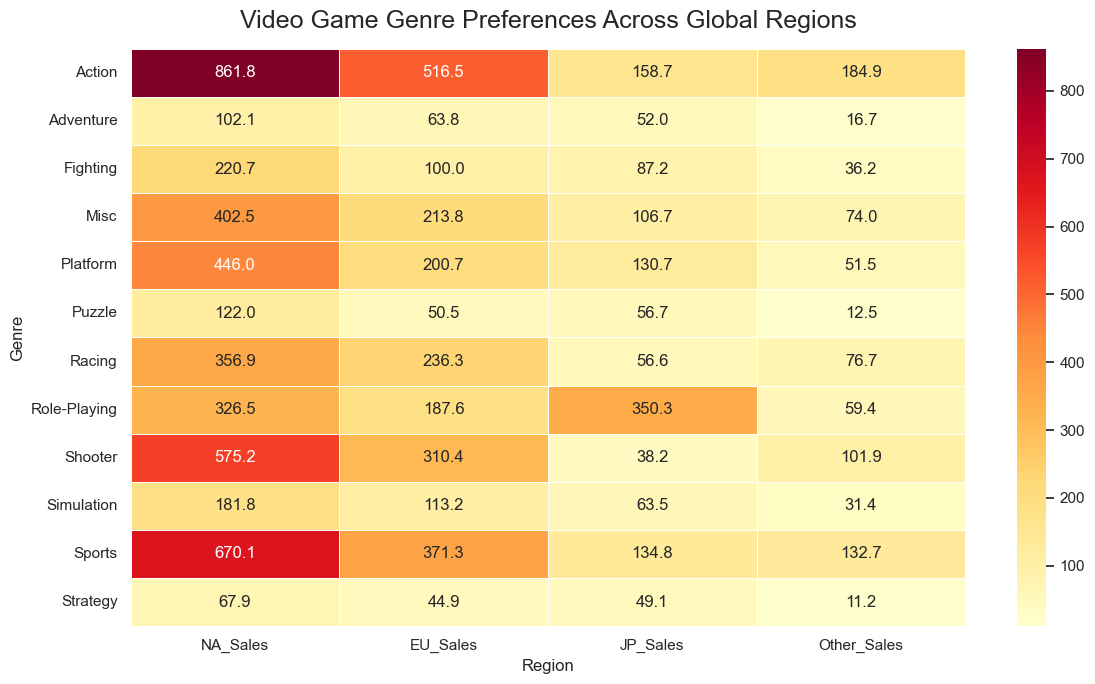

In [30]:
sns.set_style("white")

genre_region = (
    df.groupby('Genre')[
        ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
    ]
    .sum()
)

plt.figure(figsize=(12,7))

sns.heatmap(
    genre_region,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cmap="YlOrRd"
)
plt.title(
    "Video Game Genre Preferences Across Global Regions",
    fontsize=18,
    pad=15
)

plt.xlabel("Region", fontsize=12)
plt.ylabel("Genre", fontsize=12)

plt.tight_layout()

plt.show()

**15. Grafik Platform Paling Sukses**

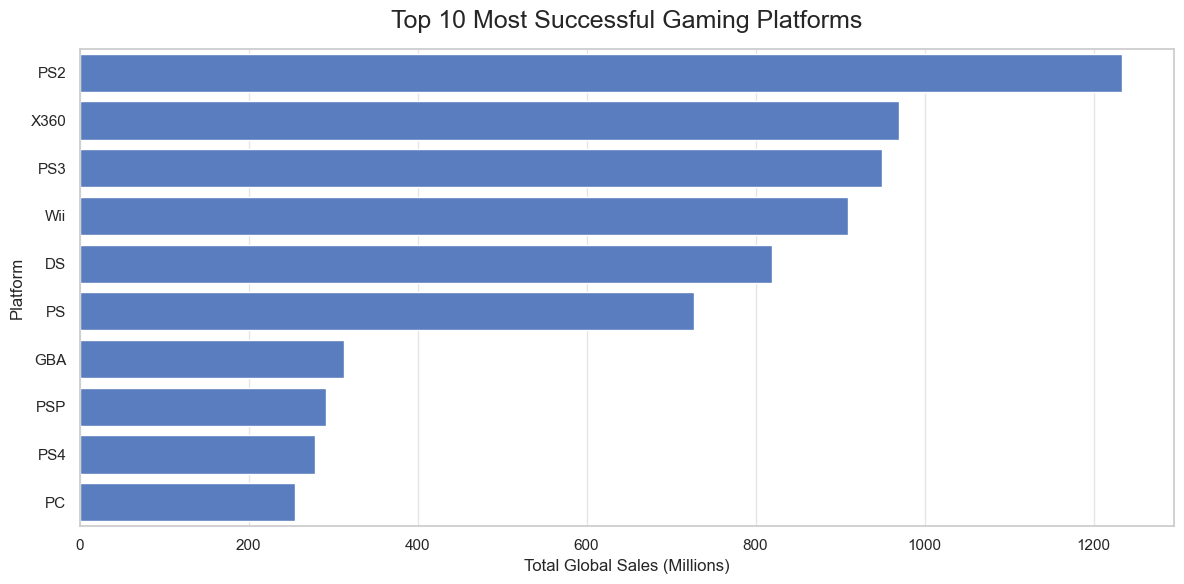

In [31]:
sns.set_style("whitegrid")

platform_sales = (
    df.groupby('Platform')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=platform_sales,
    x='Global_Sales',
    y='Platform'
)

plt.title(
    "Top 10 Most Successful Gaming Platforms",
    fontsize=18,
    pad=15
)

plt.xlabel(
    "Total Global Sales (Millions)",
    fontsize=12
)

plt.ylabel(
    "Platform",
    fontsize=12
)

plt.tight_layout()

plt.show()

**16. Top 10 Publisher Berdasarkan Total Penjualan Global**

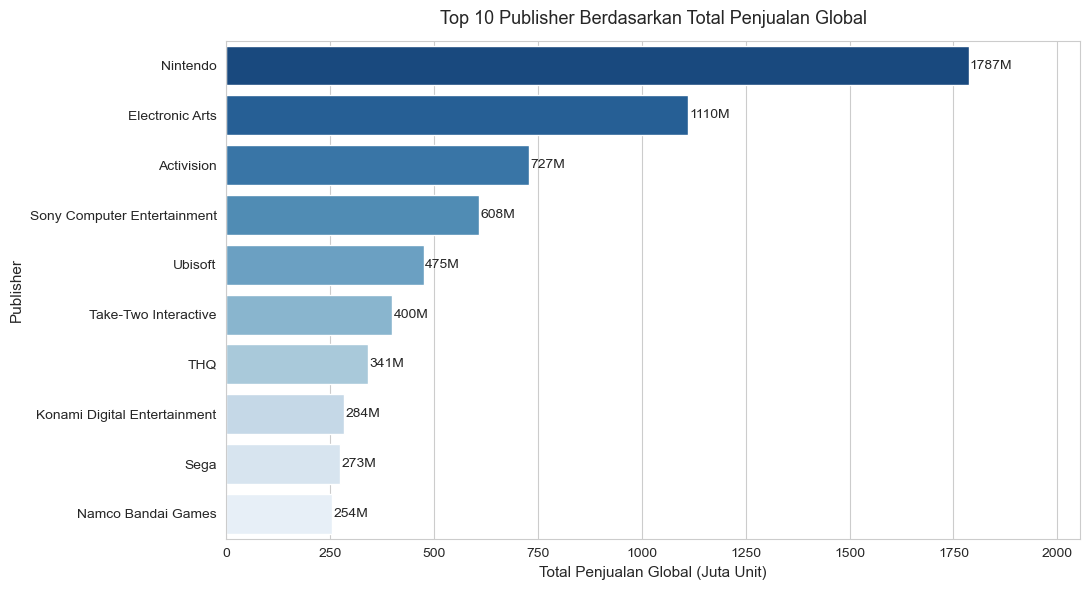

In [10]:
sns.set_style('whitegrid')

publisher_sales = (
    df.groupby('Publisher')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(11, 6))
bars = sns.barplot(
    data=publisher_sales,
    x='Global_Sales',
    y='Publisher',
    palette='Blues_r'
)
for bar in bars.patches:
    bars.text(
        bar.get_width() + 3,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.0f}M',
        va='center', ha='left', fontsize=10
    )
plt.title('Top 10 Publisher Berdasarkan Total Penjualan Global', fontsize=13, pad=12)
plt.xlabel('Total Penjualan Global (Juta Unit)', fontsize=11)
plt.ylabel('Publisher', fontsize=11)
plt.xlim(0, publisher_sales['Global_Sales'].max() * 1.15)
plt.tight_layout()
plt.show()

**Insight:** **Nintendo** mendominasi sebagai publisher terlaris di dunia, jauh melampaui kompetitor lainnya. Kekuatan franchise Nintendo (Mario, Zelda, Pokémon) yang lintas generasi menjadi faktor utamanya. EA dan Activision menyusul di posisi berikutnya berkat franchise olahraga dan FPS mereka.


**17. Scatter Plot Korelasi Penjualan NA vs EU**

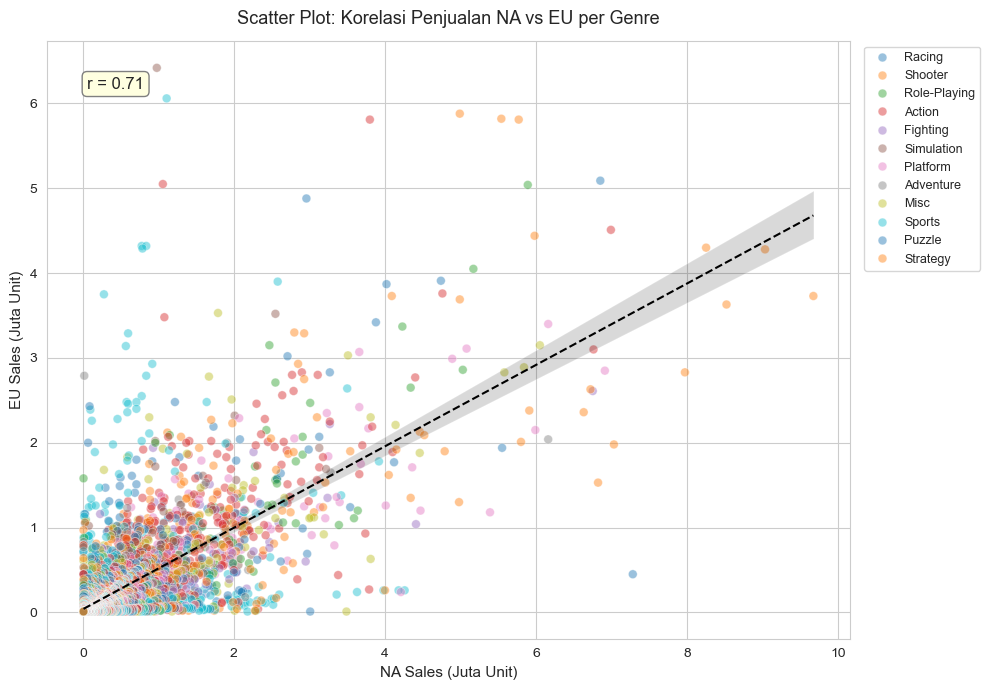

Korelasi NA_Sales vs EU_Sales: 0.7109


In [11]:
sns.set_style('whitegrid')

df_scatter = df[(df['NA_Sales'] > 0) & (df['EU_Sales'] > 0) & (df['Global_Sales'] < 15)]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_scatter,
    x='NA_Sales',
    y='EU_Sales',
    hue='Genre',
    alpha=0.45,
    s=40,
    palette='tab10'
)
sns.regplot(
    data=df_scatter,
    x='NA_Sales',
    y='EU_Sales',
    scatter=False,
    color='black',
    line_kws={'linewidth': 1.5, 'linestyle': '--'},
)
corr_val = df_scatter['NA_Sales'].corr(df_scatter['EU_Sales'])
plt.annotate(
    f'r = {corr_val:.2f}',
    xy=(0.05, 0.92), xycoords='axes fraction',
    fontsize=12,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray')
)
plt.title('Scatter Plot: Korelasi Penjualan NA vs EU per Genre', fontsize=13, pad=12)
plt.xlabel('NA Sales (Juta Unit)', fontsize=11)
plt.ylabel('EU Sales (Juta Unit)', fontsize=11)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Korelasi NA_Sales vs EU_Sales: {corr_val:.4f}')

**Insight:** Terdapat korelasi **positif kuat** antara penjualan NA dan EU — game yang laris di Amerika cenderung juga laris di Eropa. Genre **Action** dan **Sports** mendominasi dan tersebar merata di seluruh rentang nilai. Sebaliknya, **Role-Playing** cenderung bernilai EU lebih rendah relatif terhadap NA, mencerminkan perbedaan selera pasar.


**18. Heatmap Korelasi Antar Variabel Numerik**

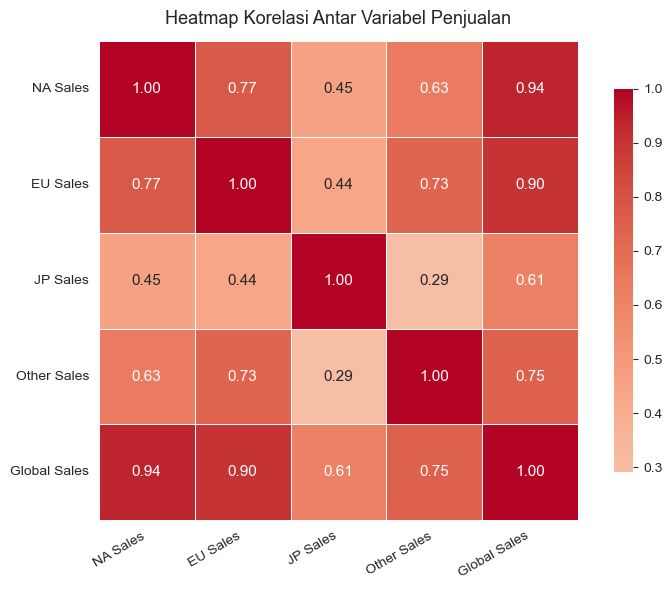

Matriks korelasi:
              NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales
NA_Sales         1.000     0.768     0.450        0.635         0.941
EU_Sales         0.768     1.000     0.436        0.726         0.903
JP_Sales         0.450     0.436     1.000        0.290         0.612
Other_Sales      0.635     0.726     0.290        1.000         0.748
Global_Sales     0.941     0.903     0.612        0.748         1.000


In [12]:
sns.set_style('white')
import numpy as np

num_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
labels   = ['NA Sales', 'EU Sales', 'JP Sales', 'Other Sales', 'Global Sales']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={'size': 11},
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Antar Variabel Penjualan', fontsize=13, pad=12)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print('Matriks korelasi:')
print(corr_matrix.round(3))

**Insight:**
- **NA Sales ↔ Global Sales** berkorelasi paling tinggi → pasar Amerika Utara adalah kontributor terbesar penjualan global.
- **JP Sales** berkorelasi paling rendah terhadap semua region → pasar Jepang memiliki selera yang unik dan independen.
- **EU Sales ↔ Other Sales** berkorelasi cukup kuat → kedua pasar ini mengikuti tren serupa.

**19. Grafik Distribusi Penjualan Video Game Global**

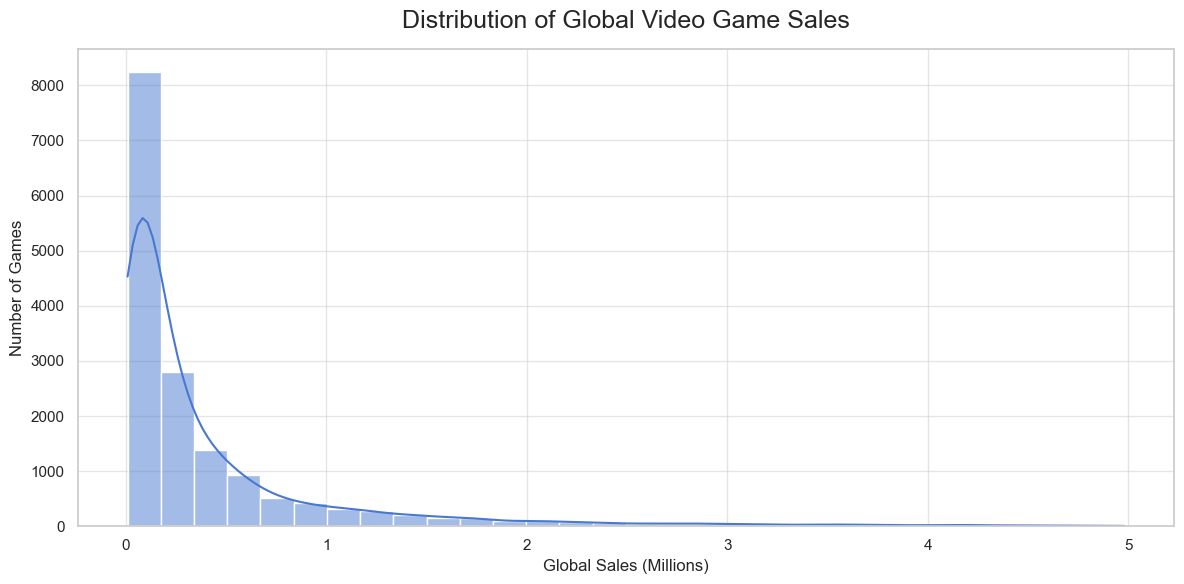

In [36]:
sns.set_style("whitegrid")
filtered_df = df[df['Global_Sales'] < 5]

plt.figure(figsize=(12,6))

sns.histplot(
    data=filtered_df,
    x='Global_Sales',
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Global Video Game Sales",
    fontsize=18,
    pad=15
)

plt.xlabel(
    "Global Sales (Millions)",
    fontsize=12
)

plt.ylabel(
    "Number of Games",
    fontsize=12
)

plt.tight_layout()

plt.show()

**20. Boxplot Outlier Penjualan per Region**

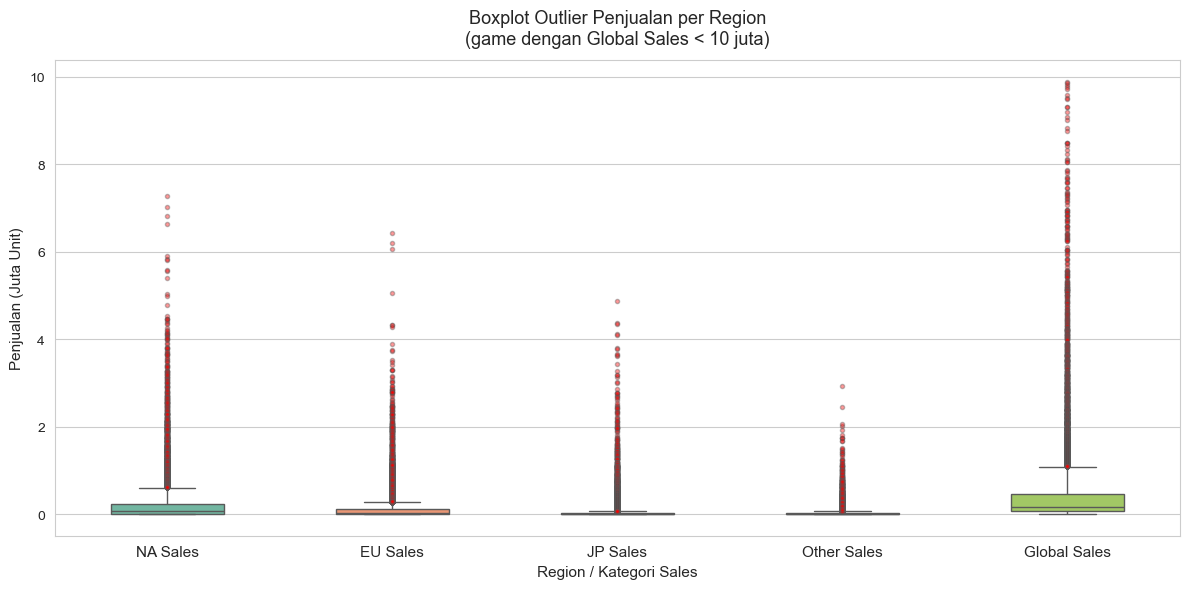

Statistik deskriptif kolom sales:
                count   mean    std   min   25%   50%   75%    max
NA_Sales      16598.0  0.265  0.817  0.00  0.00  0.08  0.24  41.49
EU_Sales      16598.0  0.147  0.505  0.00  0.00  0.02  0.11  29.02
JP_Sales      16598.0  0.078  0.309  0.00  0.00  0.00  0.04  10.22
Other_Sales   16598.0  0.048  0.189  0.00  0.00  0.01  0.04  10.57
Global_Sales  16598.0  0.537  1.555  0.01  0.06  0.17  0.47  82.74


In [ ]:
sns.set_style('whitegrid')

sales_cols  = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
label_cols  = ['NA Sales', 'EU Sales', 'JP Sales', 'Other Sales', 'Global Sales']

# Filter ekstrem biar boxplot terbaca (outlier tetap muncul sebagai titik)
df_box = df[df['Global_Sales'] < 10][sales_cols]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_box,
    palette='Set2',
    width=0.5,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.4)
)
plt.xticks(ticks=range(len(label_cols)), labels=label_cols, fontsize=11)
plt.title('Boxplot Outlier Penjualan per Region\n(game dengan Global Sales < 10 juta)', fontsize=13, pad=12)
plt.xlabel('Region / Kategori Sales', fontsize=11)
plt.ylabel('Penjualan (Juta Unit)', fontsize=11)
plt.tight_layout()
plt.show()

print("Statistik deskriptif kolom sales:")
print(df[sales_cols].describe().round(3).T)

**Insight:** Semua kolom sales berdistribusi sangat *right-skewed* dengan banyak outlier. Median jauh lebih kecil dari mean, artinya mayoritas game terjual kurang dari 1 juta unit. Region **NA** memiliki rentang outlier tertinggi, mencerminkan dominasinya di pasar global.

## 21. Rangkuman EDA

Eksplorasi data (*Exploratory Data Analysis*) ini dilakukan terhadap dataset **Video Game Sales**, 
yang berisi data penjualan video game secara global beserta informasi genre, platform, 
tahun rilis, dan regional sales (NA, EU, JP, Other).

Berikut ringkasan tahapan EDA yang telah dilakukan:

| No | Tahap | Keterangan |
|----|-------|------------|
| 1 | Import Library | Menggunakan `pandas`, `numpy`, `matplotlib`, dan `seaborn` |
| 2 | Load Dataset | Dataset dimuat dari file `video_game_sales.csv` |
| 3 | Struktur Dataset | Mengecek jumlah baris, kolom, dan nama kolom |
| 4 | Preview Data | Menampilkan 5 baris teratas dengan `df.head()` |
| 5 | Ringkasan Info | Melihat tipe data dan info umum dengan `df.info()` |
| 6 | Statistik Deskriptif | Analisis distribusi data numerik dengan `df.describe()` |
| 7 | Missing Value | Mengecek nilai yang hilang dengan `df.isnull().sum()` |
| 8 | Visualisasi Missing Value | Menampilkan Grafik Missing Value |
| 9 | Duplicate Value | Mengecek data duplikat dengan `df.duplicated().sum()` |
| 10 | Visualisasi Duplicate Value | Menampilkan Grafik Missing Value |
| 11 | Cek Inconsistent Value | Mengecek data yang tidak konsisten dengan `unique` dan `nunique` |
| 12 | Visualisasi Genre | Bar chart top 10 genre berdasarkan total penjualan global |
| 13 | Tren Tahunan | Line chart tren penjualan video game per tahun rilis |
| 14 | Preferensi Regional | Heatmap preferensi genre di setiap region (NA, EU, JP, Other) |
| 15 | Platform Terbaik | Bar chart top 10 platform berdasarkan penjualan global |
| 16 | Top Publisher | Bar Chart top 10 publisher berdasarkan penjualan global|
| 17 | Scatter Plot Sales NA vs EU | Melihat korelasi penjualan antara kedua region|
| 18 | Heatmap Korelasi Penjualan | Melihat korelasi penjualan antar region |
| 19 | Distribusi Penjualan | Histogram distribusi penjualan global (filtered < 5 juta) |
| 20 | Boxplot Outlier | Boxplot untuk menampilkan outlier |

## 22. Kesimpulan
Berdasarkan hasil EDA yang telah dilakukan, diperoleh beberapa temuan penting:

1. **Genre Terlaris** — Genre *Action* mendominasi penjualan global video game, diikuti oleh 
   *Sports* dan *Shooter*. Hal ini menunjukkan bahwa pemain secara global lebih menyukai 
   game dengan gameplay yang dinamis dan kompetitif.

2. **Tren Penjualan Tahunan** — Penjualan video game mengalami pertumbuhan signifikan dari 
   awal 2000-an hingga mencapai puncaknya sekitar tahun **2008–2009**, setelah itu terjadi 
   penurunan yang kemungkinan disebabkan oleh pergeseran tren ke platform mobile dan digital.

3. **Preferensi Genre per Region** — Setiap region memiliki selera yang berbeda:
   - **Amerika Utara (NA)** dan **Eropa (EU)** cenderung menyukai genre *Action* dan *Sports*.
   - **Jepang (JP)** memiliki preferensi unik, yaitu genre *Role-Playing (RPG)* yang jauh 
     lebih dominan dibanding region lain.

4. **Platform Paling Sukses** — Platform **PS2** menjadi platform dengan total penjualan 
   tertinggi secara global, diikuti oleh Xbox 360, PS3, dan Wii, mencerminkan era keemasan 
   konsol pada dekade 2000-an.

5. **Distribusi Penjualan** — Sebagian besar game memiliki penjualan global yang rendah 
   (di bawah 1 juta kopi), menunjukkan distribusi yang sangat *right-skewed* — hanya 
   sebagian kecil game yang berhasil menjual dalam jumlah besar (blockbuster titles).
   6. **Missing Value** — Hanya dua kolom yang memiliki missing value, yaitu `Year` (271 baris, 
   1.63%) dan `Publisher` (58 baris, 0.35%). Jumlahnya sangat kecil dibanding total 16.598 
   baris, sehingga aman untuk dihapus tanpa mengurangi kualitas analisis secara signifikan.

7. **Duplicate Value** — Dataset tidak mengandung baris duplikat sama sekali (0 duplikat), 
   sehingga seluruh data dapat dipercaya sebagai entri yang unik dan tidak perlu dilakukan 
   penghapusan duplikat pada tahap preprocessing.

8. **Outlier Penjualan** — Seluruh kolom sales (NA, EU, JP, Other, Global) menunjukkan 
   banyak outlier ekstrem di sisi kanan distribusi. Region **NA** memiliki rentang outlier 
   tertinggi, menegaskan dominasinya sebagai pasar terbesar. Nilai median yang jauh lebih 
   kecil dari mean mengonfirmasi fenomena *long tail* — segelintir game blockbuster 
   mendominasi total penjualan global.

9. **Publisher Terdominasi Nintendo** — Nintendo secara konsisten menjadi publisher dengan 
   total penjualan global tertinggi, jauh melampaui EA, Activision, dan Sony. Kekuatan 
   franchise lintas generasi seperti Mario, Zelda, dan Pokémon menjadi faktor utamanya.

10. **Korelasi NA dan EU** — Terdapat korelasi positif yang kuat antara penjualan NA dan EU, 
    artinya game yang sukses di Amerika Utara cenderung juga sukses di Eropa. Sebaliknya, 
    pasar Jepang menunjukkan pola yang lebih independen, terutama untuk genre *Role-Playing* 
    yang populer di sana namun relatif lemah di NA dan EU.

11. **Korelasi Antar Variabel** — Dari heatmap korelasi, **NA Sales** memiliki korelasi 
    tertinggi terhadap **Global Sales**, menegaskan bahwa pasar Amerika Utara adalah 
    penentu utama performa penjualan global sebuah game. **JP Sales** justru memiliki 
    korelasi paling rendah terhadap semua region lain, mencerminkan keunikan selera pasar 
    Jepang yang berdiri sendiri.

> **Catatan:** Dataset ini memiliki beberapa missing value pada kolom `Year` dan `Publisher` 
> yang perlu diperhatikan dalam analisis lanjutan.